# Daily forecast of financial time series group questions

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
import matplotlib.pylab as plt

## Get all questions

In [3]:
from get_market_pulse_25q3_questions import get_market_pulse_25q3_questions
ifps = get_market_pulse_25q3_questions()

200


In [4]:
import json
if 0:
    from get_underlying_urls import get_underlying_urls
    results = get_underlying_urls(ifps)
    with open('results.json', 'w') as f:
        json.dump(results, f, indent=4)
else:
    with open('results.json', 'r') as f:
        results = json.load(f)

## Acquire question data

In [5]:
from urls_to_ticker import urls_to_ticker
from pprint import pprint
sources = []
for key, (title, urls) in results.items():
    sources.extend(urls_to_ticker(urls))

In [6]:
sources = list(sorted(set(sources)))

In [7]:
import os, joblib
from get_data_for import get_data_for
if os.path.exists('history.joblib'):
    history = joblib.load('history.joblib')
else:
    history = {(x,y,z): get_data_for(x,y,z) for x,y,z in sources}
    joblib.dump(history, 'history.joblib');

In [8]:
group_id_to_data = {int(x): results[x] for x in results}

In [9]:
results = {int(key): value for key, value in results.items()}

In [10]:
for ifp in ifps:
    ifp['sources'] = urls_to_ticker(results[ifp['group']['id']][1])
    ifp['data'] = {x: history[x] for x in ifp['sources']}
    if 'following companies' in ifp['title']:
        company = ifp['title'].split('(')[1].split(')')[0]
        ifp['sources'] = [(x,y,z) for x,y,z in ifp['sources'] if y == company]
        ifp['data'] = {(x,y,z):w for (x,y,z),w in ifp['data'].items() if y == company}

## Get forward period start and end date

In [11]:
from get_forward_period_start_and_end_date import get_forward_period_start_and_end_date

In [15]:
for ifp in ifps:
    if 'period' not in ifp:
        ifp['period'] = get_forward_period_start_and_end_date(ifp)

In [16]:
with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

## Parse observable of data

In [18]:
from get_observable import get_observable
import pandas as pd
pd.set_option('display.max_colwidth', 1000)

In [19]:
from get_period_type import get_period_type

In [22]:
for i, ifp in enumerate(ifps):
    if 'observable' not in ifp:
        ifp['observable'] = get_observable(ifp)
        ifp['period_type'] = get_period_type(ifp)

In [23]:
with open('results.json', 'w') as f:
    json.dump(results, f, indent=4)

## Generate forecast for each question

### High on any day in forward biweekly period from today

What will be the maximum intraday value of the VIX over the following biweekly periods in Q3, 2025? (July 21 - Aug 1)


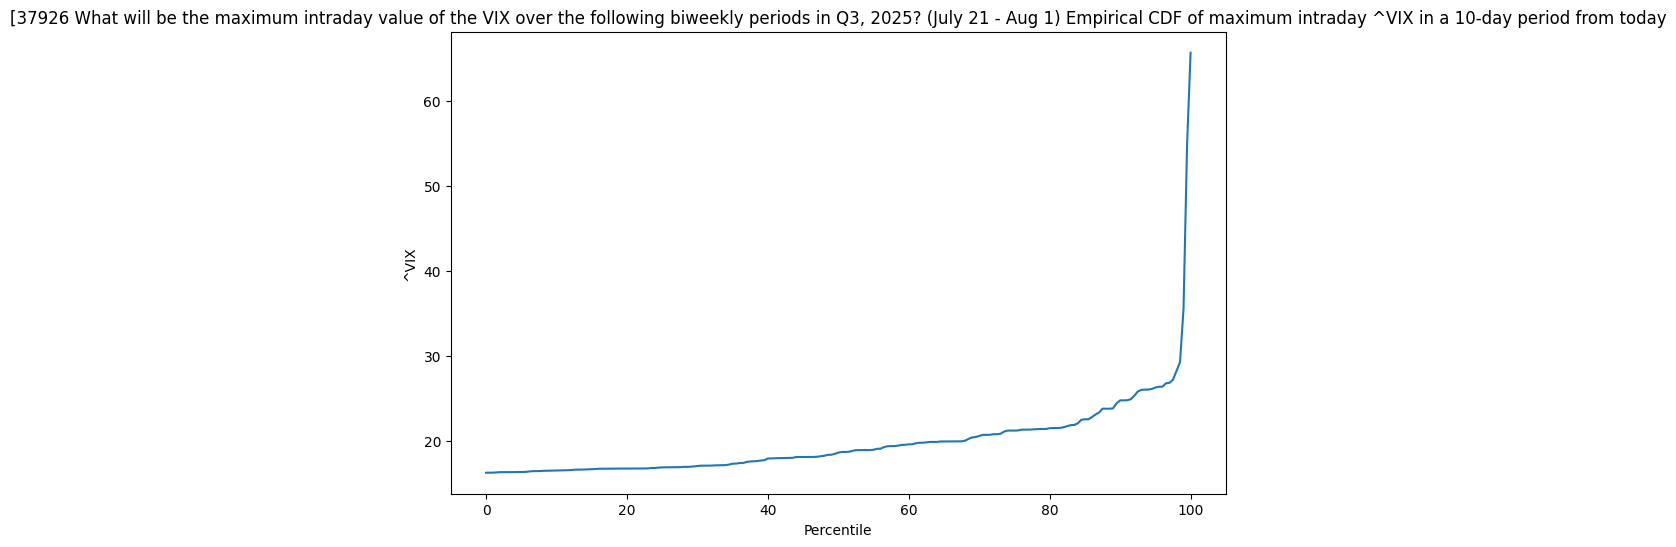

In [75]:
from forecast_high_on_any_day_in_forward_period import forecast_high_on_any_day_in_forward_period
ifp = ifps[0]
if ifp['observable'] == 'High' and ifp['period_type'] == 'any day in biweekly period':
    rng, forecast = forecast_high_on_any_day_in_forward_period(ifp)

### Close on last day of biweekly period

What will be the ending value of the ICE BofA US High Yield Option-Adjusted Spread for the following biweekly periods? (Jul 21 - Aug 1)
('last day of biweekly period', ['2025-07-21', '2025-08-01'], 'Close')


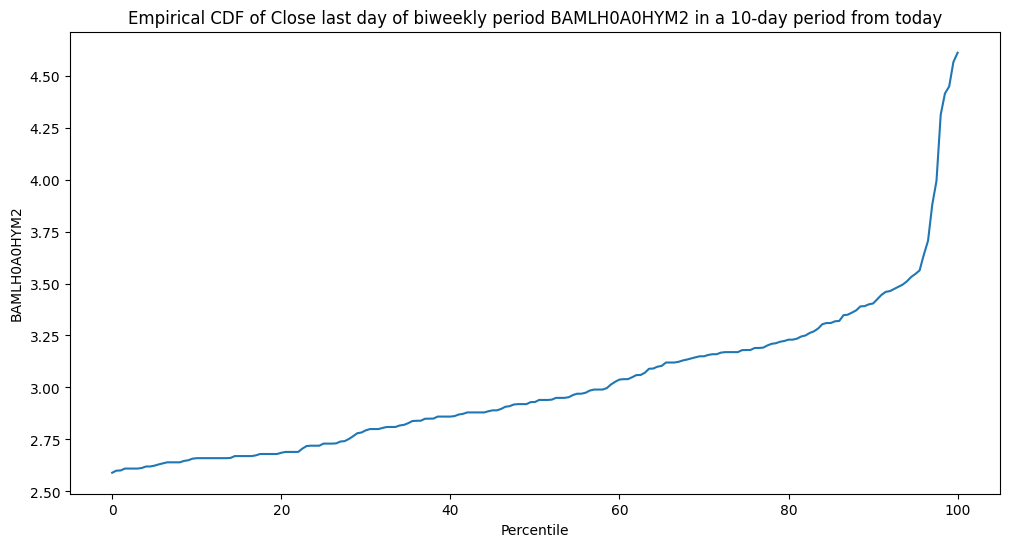

In [78]:
from forecast_close_on_last_day_of_period import forecast_close_on_last_day_of_period
ifp = ifps[2]
if ifp['observable'] == 'Close' and ifp['period_type'] == 'last day of biweekly period':
    rng, forecast = forecast_close_on_last_day_of_period(ifp)

### period stock price return on last vs first day of biweekly period

How much will Nvidia's stock price returns exceed Apple's in the following biweekly periods of Q3 2025? (Jul 21 - Aug 1)
('return on last vs first day of biweekly period', ['2025-07-21', '2025-08-01'], 'stock price Close return')


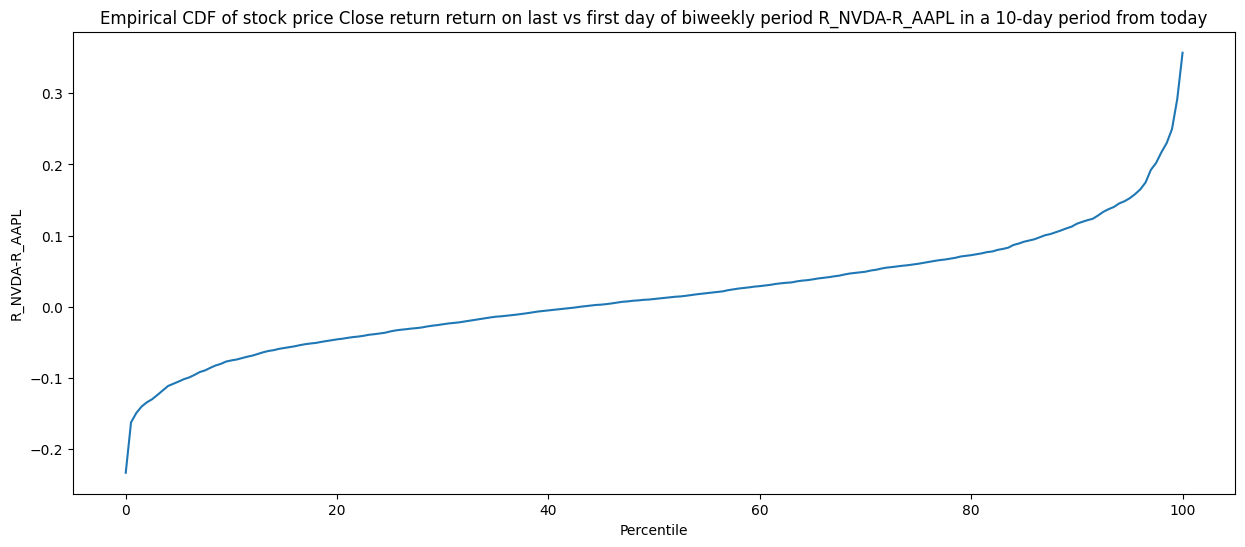

In [67]:
from forecast_stock_price_return_spread import forecast_stock_price_return_spread
ifp = ifps[4]
if (ifp['observable'], ifp['period_type']) == ('stock price Close return', 'return on last vs first day of biweekly period'):
    rng, forecast = forecast_stock_price_return_spread(ifp)

### period futures total price return on last vs first day of biweekly period

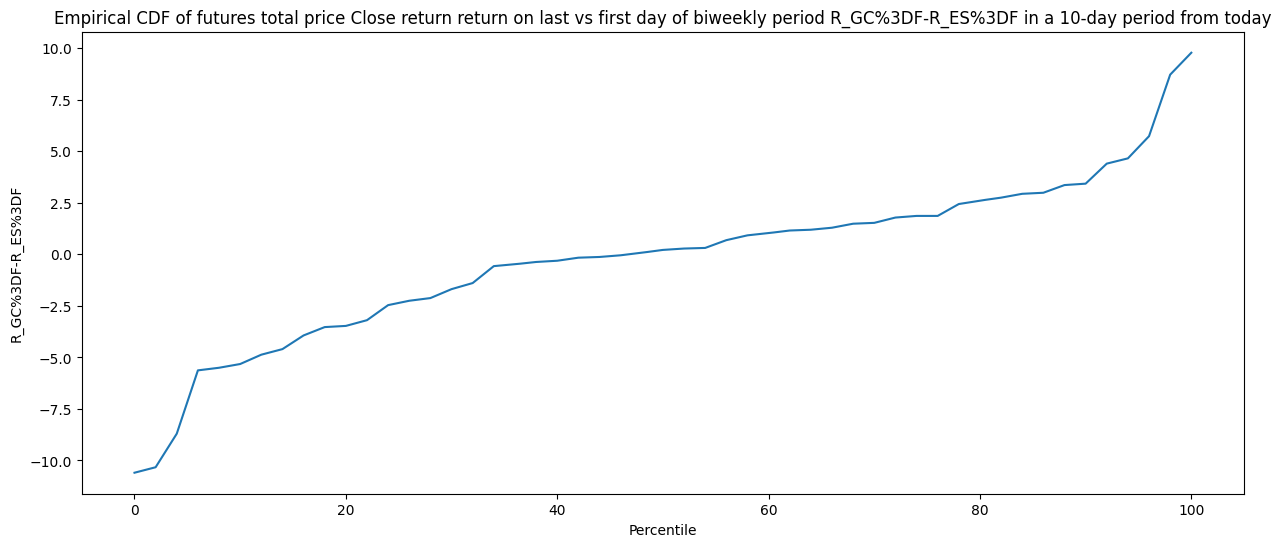

In [73]:
from forecast_futures_total_price_return_spread import forecast_futures_total_price_return_spread
ifp = ifps[13]
if (ifp['observable'], ifp['period_type']) == ('futures total price Close return', 'return on last vs first day of biweekly period'):
    rng, forecast = forecast_futures_total_price_return_spread(ifp)

### quarter diluted eps on next SEC filing date	

In [50]:
from forecast_eps_distribution import forecast_eps_distribution

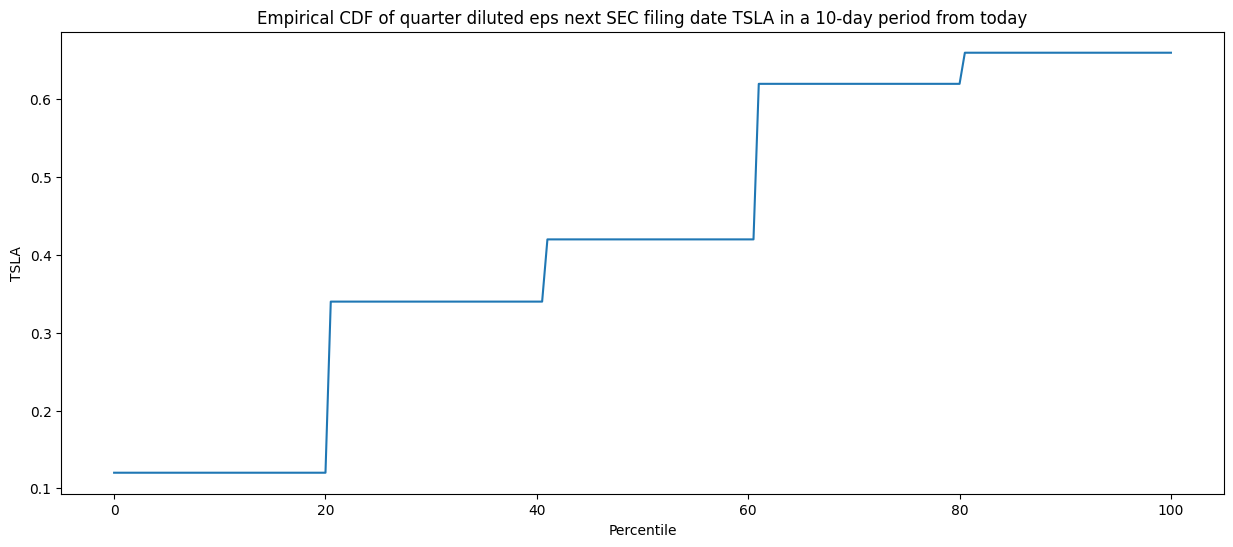

In [63]:
ifp = ifps[16]
if (ifp['observable'], ifp['period_type']) == ('quarter diluted eps', 'next SEC filing date'):
    title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]].dropna()
    underlying = ifp['sources'][0][1]
    rng, forecast = forecast_eps_distribution(data)
    plt.figure(figsize=(15,6))
    plt.plot(rng, forecast);
    plt.ylabel(underlying)
    plt.xlabel('Percentile')
    plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

### quarter total revenue on next SEC filing date	

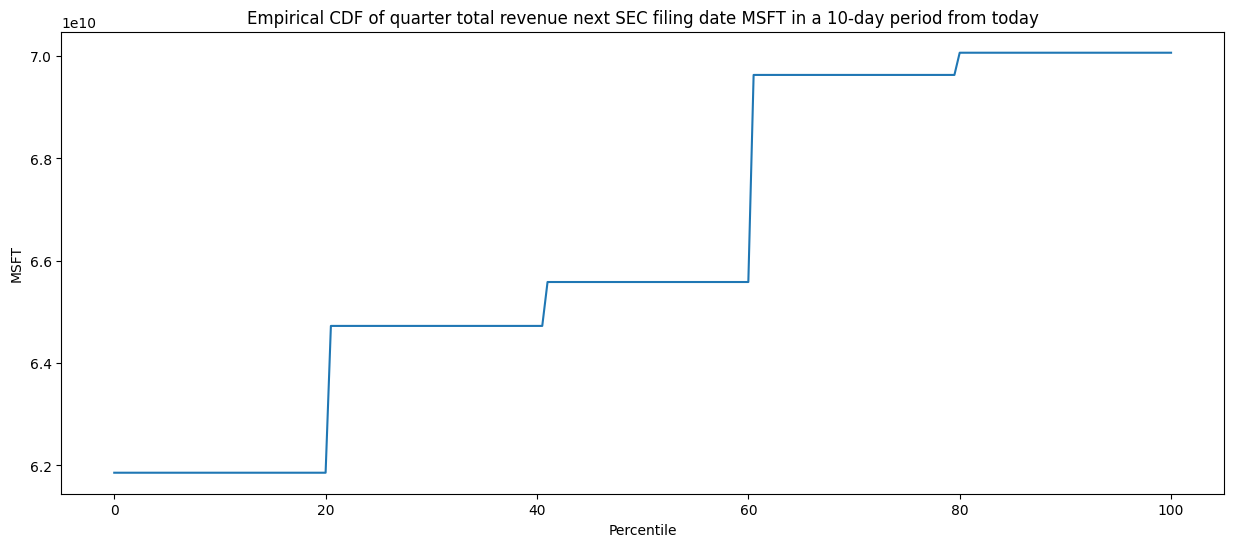

In [62]:
ifp = ifps[25]
if ('quarter total revenue', 'next SEC filing date') == ('quarter total revenue', 'next SEC filing date'):
    title, observable, period_type, period, data = ifp['title'], ifp['observable'],  ifp['period_type'],  ifp['period'], ifp['data'][ifp['sources'][0]].dropna()
    underlying = ifp['sources'][0][1]
    rng, forecast = forecast_eps_distribution(data)
    plt.figure(figsize=(15,6))
    plt.plot(rng, forecast);
    plt.ylabel(underlying)
    plt.xlabel('Percentile')
    plt.title(f'Empirical CDF of {observable} {period_type} {underlying} in a 10-day period from today');

## Submit the question

## Repeat until all questions are forecast

## Automate and rerun

## Assess crowd alignment

In [ ]:
ifp['group']['group_of_questions'].keys()

In [ ]:
print(ifp['group']['group_of_questions']['resolution_criteria'])

In [ ]:
vix = ifp['inputs'][('yahoo', '^VIX', 'price')]

In [ ]:
ifp['title']

In [ ]:
vix['Close']['^VIX'].plot();

In [ ]:
df_vix = vix[['High']]

In [ ]:
df_vix.columns = ['^VIX']

In [ ]:
ifp['title']

In [ ]:
today = str(datetime.now())[0:10]
today

In [ ]:
future_start = '2025-07-21'
future_end = '2025-08-01'

In [ ]:
cdf_vix = conditional_future_vix_max_cdf(
    df_vix,             # DataFrame with Date index & column '^VIX'
    today,                   # Today's date as 'YYYY-MM-DD'
    future_start,            # Start of window as 'YYYY-MM-DD'
    future_end,              # End of window as 'YYYY-MM-DD'
    band=0.5                # Conditioning band in VIX units, e.g. ±0.5
)

In [ ]:
pdf_vix = cdf_to_pdf(cdf_vix)

In [ ]:
percentiles = np.arange(0,100.5,0.5)

In [ ]:
plt.plot(percentiles, pdf_vix);

In [ ]:
%matplotlib inline
import matplotlib.pylab as plt
plt.plot(percentiles, cdf_vix);